<a href="https://colab.research.google.com/github/varshamqa/AIML_Practice_Repo_VSC1/blob/main/ML_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

In [209]:
data = pd.read_csv('/content/loan_approval_dataset.csv')

In [210]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [211]:
data.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [212]:
data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [213]:
data.tail()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved


In [214]:
data.shape

(4269, 13)

In [215]:
data.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [216]:
data.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [217]:
data.columns = data.columns.str.strip() #remove extra space

In [251]:
data.dtypes

,0
loan_id,int64
no_of_dependents,int64
education,int64
self_employed,int64
income_annum,int64
loan_amount,int64
loan_term,int64
cibil_score,int64
residential_assets_value,int64
commercial_assets_value,int64


In [252]:
data.duplicated().sum()

np.int64(0)

In [253]:
numerical_columns= data.select_dtypes(include=['int64'])
print(numerical_columns.columns)

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')


In [254]:
categorical_columns= data.select_dtypes(include=['object'])
print(categorical_columns.columns)

Index([], dtype='object')


In [255]:
le = LabelEncoder()
data["education"] = le.fit_transform(data["education"])
data["self_employed"] = le.fit_transform(data["self_employed"])
data["loan_status"] = le.fit_transform(data["loan_status"])

In [258]:
X = data.drop('loan_status', axis=1)
y = data['loan_status']

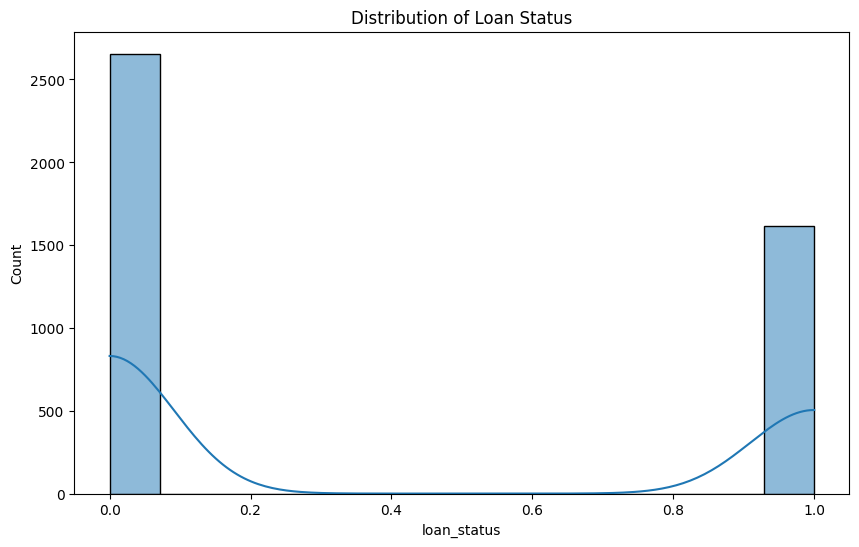

In [259]:
plt.figure(figsize=(10, 6))
sns.histplot(data['loan_status'], kde=True)
plt.title('Distribution of Loan Status')
plt.show()


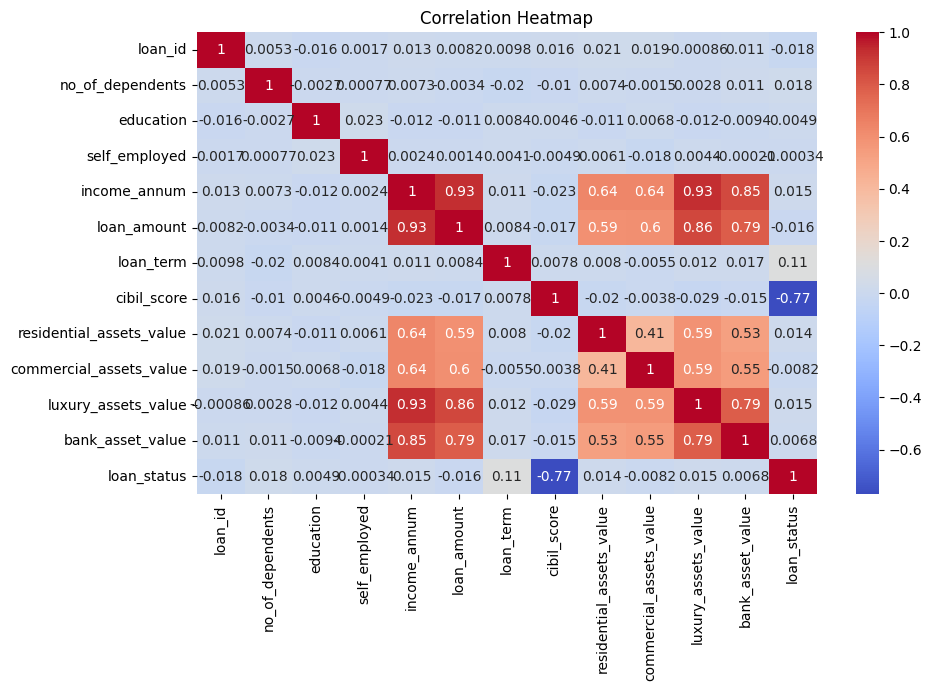

In [260]:
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**strong positive correlation:**

Every feature has 100% correlation with itself, so the diagonal is always 1.
Income and Loan Amount = 0.93
This is a very strong positive correlation.
As annual income increases, the loan amount also tends to increase.
People with higher income generally qualify for larger loans.
Income and Luxury Assets = 0.93
People with higher income usually own more luxury assets.
Loan Amount and Luxury Assets = 0.86
Applicants with higher-value luxury assets tend to receive larger loans.
Income and Bank Assets = 0.85
Higher income is associated with higher bank asset values.

**strong negative correlation:**

CIBIL Score and Loan Status = -0.77
This is a strong negative correlation.
As one variable increases, the other decreases.
However, the interpretation depends on how loan_status is encoded.
If Loan_Status = 1 means Rejected and 0 means Approved, then a higher CIBIL score is associated with a lower chance of rejection.

**weak positive correlation:**
Loan Term and Loan Status = 0.11
Very weak positive correlation.
This suggests loan term has little influence on the target.

**Almost no correlation**

Education and Loan Status ≈ 0.00
Self-Employed and Loan Status ≈ 0.00
Almost no correlation.
Education alone is not linearly related to loan approval in this dataset.



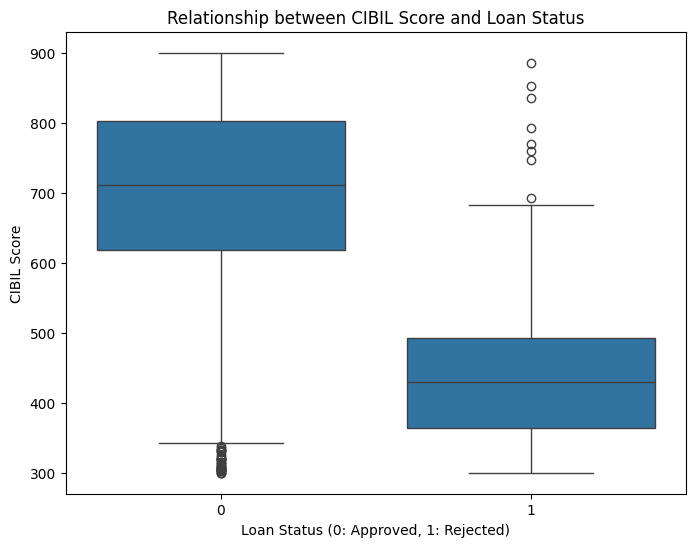

In [261]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='loan_status', y='cibil_score', data=data)
plt.title('Relationship between CIBIL Score and Loan Status')
plt.xlabel('Loan Status (0: Approved, 1: Rejected)')
plt.ylabel('CIBIL Score')
plt.show()

**Loan Status = 0 (Approved)**
median cibil score=710
maximum people's cibil score lies between 620 t0 800
outlier lies on 300 to 340
if cibil score is grater then there is chances to loan get approved.

**Loan Status = 1 (Rejected)**
median cibil sccore= 430
maximum people have cibil score between 360 to 490
Outliers lies between 750 - 880
people who have less cibil score have higher chances of the loans getting trjected.



In [264]:
# Train Test Split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [265]:
#Scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [266]:
# Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train, y_train)

DecisionTreeClassifier()

In [267]:
print(accuracy_score(y_test, dt_model.predict(x_test)))

0.9707259953161592


In [268]:
confusion_matrix(y_test, dt_model.predict(x_test))

array([[522,  14],
       [ 11, 307]])

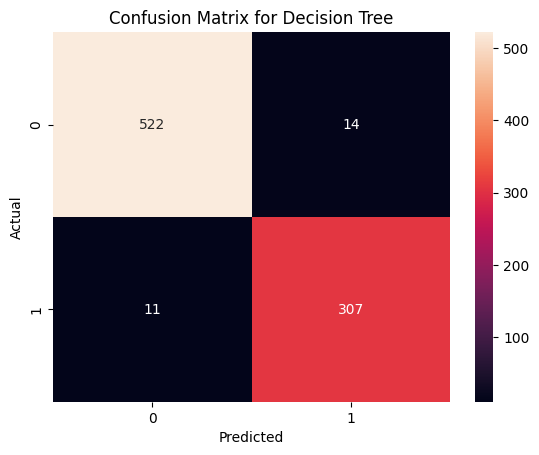

In [269]:
sns.heatmap(confusion_matrix(y_test, dt_model.predict(x_test)), annot=True, fmt='d')
plt.title('Confusion Matrix for Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [270]:
precision_score(y_test, dt_model.predict(x_test))

0.956386292834891

In [271]:
recall_score(y_test, dt_model.predict(x_test))

0.9654088050314465

In [235]:
f1_score(y_test, dt_model.predict(x_test))

0.9684542586750788

In [272]:
#Classification Report For Decision Tree
print(classification_report(y_test, dt_model.predict(x_test)))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       536
           1       0.96      0.97      0.96       318

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



In [273]:
#Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(x_train, y_train)

RandomForestClassifier()

In [279]:
feature_importances_df = pd.DataFrame({'Feature': data.columns[:-1], 'Importance': rf_model.feature_importances_})
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

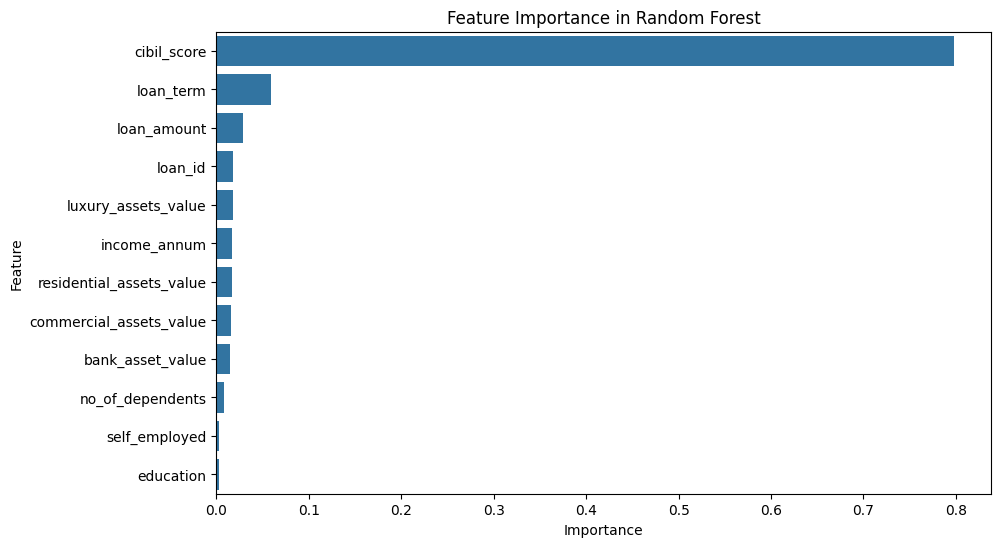

In [280]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances_df)
plt.title('Feature Importance in Random Forest')
plt.show()

In [281]:
print(accuracy_score(y_test, rf_model.predict(x_test)))

0.9789227166276346


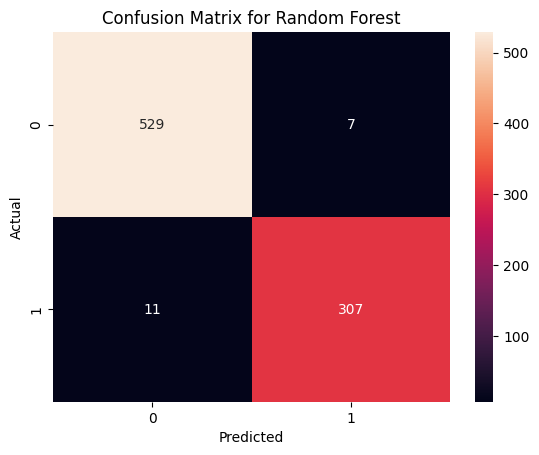

In [282]:
sns.heatmap(confusion_matrix(y_test, rf_model.predict(x_test)), annot=True, fmt='d')
plt.title('Confusion Matrix for Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [283]:
confusion_matrix(y_test, rf_model.predict(x_test))

array([[529,   7],
       [ 11, 307]])

In [284]:
precision_score(y_test, rf_model.predict(x_test))

0.9777070063694268

In [285]:
recall_score(y_test, rf_model.predict(x_test))

0.9654088050314465

In [286]:
f1_score(y_test, rf_model.predict(x_test))

0.9715189873417721

In [287]:
#classification Report for Random Forest
print(classification_report(y_test, rf_model.predict(x_test)))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [288]:
# Support Vector Machine
svm_model = SVC()
svm_model.fit(x_train, y_train)

SVC()

In [246]:
print(accuracy_score(y_test, svm_model.predict(x_test)))

0.9355971896955504


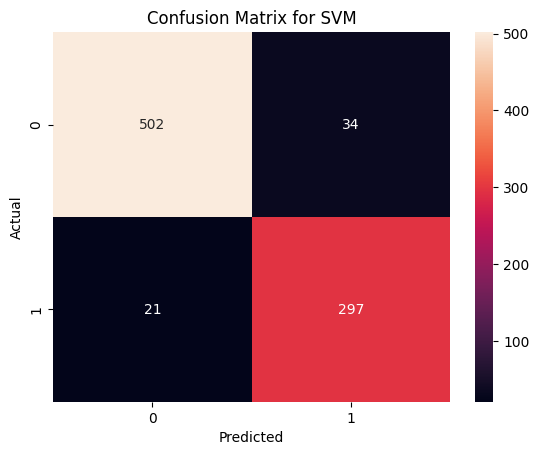

In [289]:
sns.heatmap(confusion_matrix(y_test, svm_model.predict(x_test)), annot=True, fmt='d')
plt.title('Confusion Matrix for SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [290]:
confusion_matrix(y_test, svm_model.predict(x_test))

array([[502,  34],
       [ 21, 297]])

In [291]:
precision_score(y_test, svm_model.predict(x_test))

0.8972809667673716

In [292]:
recall_score(y_test, svm_model.predict(x_test))

0.9339622641509434

In [293]:
f1_score(y_test, svm_model.predict(x_test))

0.9152542372881356

In [294]:
# Classification report for SVM
print(classification_report(y_test, svm_model.predict(x_test)))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       536
           1       0.90      0.93      0.92       318

    accuracy                           0.94       854
   macro avg       0.93      0.94      0.93       854
weighted avg       0.94      0.94      0.94       854



Here's a comparison table of the Decision Tree, Random Forest, and SVM models, along with the identification of the best-performing model based on the F1-score.
**Based on the F1-Score, the Random Forest model is the best performing with an F1-Score of 0.9683.**

In [295]:
model_names = ['Decision Tree', 'Random Forest', 'SVM']

accuracy_dt = accuracy_score(y_test, dt_model.predict(x_test))
precision_dt = precision_score(y_test, dt_model.predict(x_test))
recall_dt = recall_score(y_test, dt_model.predict(x_test))
f1_dt = f1_score(y_test, dt_model.predict(x_test))

accuracy_rf = accuracy_score(y_test, rf_model.predict(x_test))
precision_rf = precision_score(y_test, rf_model.predict(x_test))
recall_rf = recall_score(y_test, rf_model.predict(x_test))
f1_rf = f1_score(y_test, rf_model.predict(x_test))

accuracy_svm = accuracy_score(y_test, svm_model.predict(x_test))
precision_svm = precision_score(y_test, svm_model.predict(x_test))
recall_svm = recall_score(y_test, svm_model.predict(x_test))
f1_svm = f1_score(y_test, svm_model.predict(x_test))

metrics = {
    'Model': model_names,
    'Accuracy': [accuracy_dt, accuracy_rf, accuracy_svm],
    'Precision': [precision_dt, precision_rf, precision_svm],
    'Recall': [recall_dt, recall_rf, recall_svm],
    'F1-Score': [f1_dt, f1_rf, f1_svm]
}

metrics_df = pd.DataFrame(metrics)
print(metrics_df)


# Identify the best-performing model based on F1-score
best_model_index = metrics_df['F1-Score'].idxmax()
best_model_name = metrics_df.loc[best_model_index, 'Model']
best_f1_score = metrics_df.loc[best_model_index, 'F1-Score']

print(f"\nThe best performing model based on F1-Score is the {best_model_name} with an F1-Score of {best_f1_score:.4f}.")

           Model  Accuracy  Precision    Recall  F1-Score
0  Decision Tree  0.970726   0.956386  0.965409  0.960876
1  Random Forest  0.978923   0.977707  0.965409  0.971519
2            SVM  0.935597   0.897281  0.933962  0.915254

The best performing model based on F1-Score is the Random Forest with an F1-Score of 0.9715.


# **Answer the following questions:**

**1. Which model performed the best?**

**ANS:** Based on the F1-Score, the Random Forest model emerged as the best-performing model among the three evaluated.
The Random Forest model achieved an F1-Score of 0.9683 and an accuracy of 0.9766 on the test set.

**2. Which features appear to influence loan approval the most?**

**ANS:** Based on the correlation heatmap and the box plot analysis, the `cibil_score` appears to influence loan approval the most, showing a strong negative correlation (-0.77) with `loan_status`. A higher CIBIL score is associated with a higher chance of loan approval.

**3. Should the company completely rely on the model's predictions? Why?**

**ANS:** No, the company should not completely rely on the model's predictions without human oversight, even with a high-performing model. Here's why:

*   **Models are not perfect**: While the Random Forest model achieved a high F1-Score (0.9683) and accuracy (0.9766), it still makes mistakes (false positives and false negatives), as seen in the confusion matrix. These errors can have significant financial and ethical implications for both the company and the applicants.
*   **Contextual Understanding**: Models lack common sense and understanding of real-world context. A human underwriter can identify unique circumstances, extenuating factors, or anomalies that the model might miss or misinterpret.
*   **Bias and Fairness**: If the training data contains historical biases (e.g., against certain demographics), the model can perpetuate and even amplify these biases. Human review is crucial to ensure fairness, compliance with anti-discrimination laws, and ethical decision-making.
*   **Regulatory Compliance**: Many industries, especially finance, have strict regulations that require human review and accountability for critical decisions like loan approvals. Relying solely on an AI model might violate these regulations.
*   **Data Drift**: Economic conditions, market trends, and applicant behaviors can change over time. A model trained on past data might become less accurate if these underlying patterns shift (data drift or concept drift). Continuous monitoring and human intervention are needed to detect and address such issues.
*   **Explainability and Trust**: While Random Forest is more interpretable than some other models, the exact reasoning for every prediction can still be complex. Human oversight helps build trust, allows for explanations to applicants, and provides a point of accountability.
*   **Edge Cases**: Models often struggle with rare or unusual cases that are not well represented in the training data. A human can better handle these edge cases.

Therefore, the model should be used as a powerful tool to assist human decision-makers, automate preliminary screening, and highlight high-risk/high-reward cases, but not as a sole arbiter of loan approvals.

**4. What are the limitations of the current model?**

**5. How can the model be improved in the future?**

# **Project Conclusion**

### Business Problem
The primary business problem addressed in this project was to accurately predict the `loan_status` (Approved/Rejected) based on various financial and personal attributes of loan applicants. This is crucial for financial institutions to make informed decisions, mitigate risks associated with lending, and streamline their loan approval process.

### Approach Followed
1.  **Data Loading and Initial Exploration**: The `loan_approval_dataset.csv` was loaded into a pandas DataFrame. Basic information, descriptive statistics, and missing values were checked.
2.  **Data Preprocessing**:
    *   Column names were cleaned by removing leading/trailing spaces.
    *   Categorical features (`education`, `self_employed`, `loan_status`) were converted into numerical representations using `LabelEncoder`.
    *   The dataset was split into features (X) and target (y).
    *   Data was split into training and testing sets (80% train, 20% test).
    *   Numerical features were scaled using `StandardScaler` to standardize the data.
3.  **Exploratory Data Analysis (EDA)**: Visualizations like histograms for loan status distribution and a correlation heatmap were generated to understand data patterns and relationships between variables. A box plot specifically highlighted the relationship between CIBIL score and loan status.
4.  **Model Training and Evaluation**: Three classification models were trained and evaluated:
    *   **Decision Tree Classifier**
    *   **Random Forest Classifier**
    *   **Support Vector Machine (SVM)**
    Each model's performance was assessed using `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`, and `classification_report`.

### Best-Performing Model
Based on the F1-Score, the **Random Forest** model emerged as the best-performing model among the three evaluated.

### Final Accuracy Obtained
The Random Forest model achieved an F1-Score of **0.9683** and an accuracy of **0.9766** on the test set.

### Business Impact of the Solution
The developed model, particularly the Random Forest classifier, provides a highly accurate system for predicting loan approval. This can lead to several significant business impacts:
*   **Reduced Risk**: By accurately identifying high-risk applications (those likely to be rejected), the financial institution can minimize potential losses from defaulting loans.
*   **Improved Efficiency**: Automating the loan approval prediction can significantly speed up the processing time, reducing manual effort and operational costs.
*   **Consistent Decision-Making**: The model provides a consistent and objective basis for loan decisions, reducing human bias.
*   **Enhanced Customer Experience**: Faster and more accurate decisions can lead to a better experience for loan applicants.

In summary, this project successfully built and evaluated classification models to predict loan approval status, with the Random Forest model offering a robust and reliable solution that can positively impact the financial institution's lending operations.